10. In this problem, you will generate simulated data, and then perform
PCA and K-means clustering on the data.

(a) Generate a simulated data set with 20 observations in each of
three classes (i.e. 60 observations total), and 50 variables.
Hint: There are a number of functions in Python that you can
use to generate data. One example is the normal() method of
the random() function in numpy; the uniform() method is another
option. Be sure to add a mean shift to the observations in each
class so that there are three distinct classes.

In [6]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

n_per_class = 20
n_classes = 3
p = 50 

shift = {
    0: np.r_[np.full(5,-4.0),np.zeros(p-5)],
    1: np.r_[np.zeros(5),np.zeros(p-5)],
    2: np.r_[np.full(5,4.0),np.zeros(p-5)]
}

Xs, ys = [], []
for c in range (n_classes):
    Xc = rng.normal(loc=0.0, scale=1.0, size=(n_per_class, p)) + shift[c]
    Xs.append(Xc)
    ys.append(np.full(n_per_class,c))
    
X = np.vstack(Xs)
y = np.concatenate(ys)
df = pd.DataFrame(X, columns=[f"x{j+1}" for j in range (p)])
df["y_true"] = y

print("X shape:", X.shape)
print("y distribution:", np.bincount(y))

X shape: (60, 50)
y distribution: [20 20 20]


(b) Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a different color to indicate
the observations in each of the three classes. If the three classes
appear separated in this plot, then continue on to part (c). If
not, then return to part (a) and modify the simulation so that
there is greater separation between the three classes. Do not
continue to part (c) until the three classes show at least some

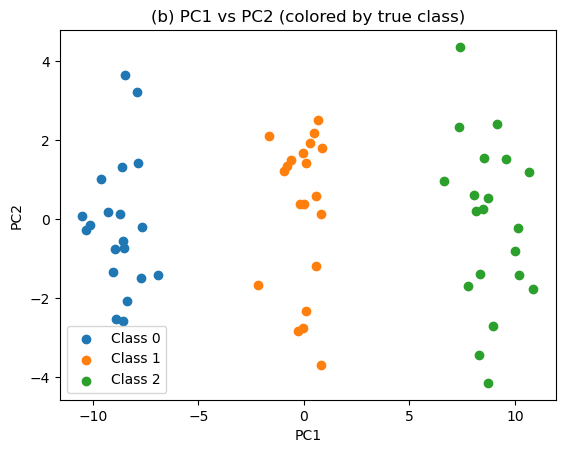

Explained variance ratio (PC1, PC2): [0.51928086 0.03506194]


In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components =  2, random_state = 42)
scores_2d = pca.fit_transform(X)

plt.figure()
for c in np.unique(y):
    idx = (y==c)
    plt.scatter(scores_2d[idx,0], scores_2d[idx,1], label=f"Class {c}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("(b) PC1 vs PC2 (colored by true class)")
plt.legend()
plt.show()

print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)

(c) Perform K-means clustering of the observations with K = 3.
How well do the clusters that you obtained in K-means clustering compare to the true class labels?
Hint: You can use the pd.crosstab() function in Python to compare the true class labels to the class labels obtained by clustering. Be careful how you interpret the results: K-means clustering
will arbitrarily number the clusters, so you cannot simply check
whether the true class labels and clustering labels are the same.

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def summarize_clustering(y_true, y_pred, title=""):
    ct = pd.crosstab(pd.Series(y_true, name="True"),
                     pd.Series(y_pred, name="Cluster"))
    ari = adjusted_rand_score(y_true, y_pred)
    print(title)
    print(ct)
    print("Adjusted Rand Index(ARI):", round(ari,3))
    return ct, ari

k3_raw = KMeans(n_clusters=3, n_init=20)
labels_k3_raw = k3_raw.fit_predict(X)

ct_k3_raw, ari_k3_raw = summarize_clustering(y, labels_k3_raw, title="(c)K=3 on raw data")

(c)K=3 on raw data
Cluster   0   1   2
True               
0        20   0   0
1         0   0  20
2         0  20   0
Adjusted Rand Index(ARI): 1.0


c:\Users\User-NB\anaconda3\envs\tbrain_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


(d) Perform K-means clustering with K = 2. Describe your results.

In [18]:
k2_raw = KMeans(n_clusters=2, n_init=20)
labels_k2_raw = k2_raw.fit_predict(X)

ct_k2_raw, ari_k2_raw = summarize_clustering(y, labels_k2_raw,title="(d) K=2 on raw data")

(d) K=2 on raw data
Cluster   0   1
True           
0         0  20
1         0  20
2        20   0
Adjusted Rand Index(ARI): 0.563


c:\Users\User-NB\anaconda3\envs\tbrain_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


With K = 2, K-means merged Classes 0 and 1 into one cluster and placed Class 2 separately.
This shows that Classes 0 and 1 are more similar in the feature space, while Class 2 is distinct.
The ARI = 0.563 indicates a moderate match between the clustering and true labels.

(e) Now perform K-means clustering with K = 4, and describe your
results.

In [21]:
k4_raw = KMeans(n_clusters=4, n_init=20)
labels_k4_raw = k4_raw.fit_predict(X)

ct_k4_raw, ari_k4_raw = summarize_clustering(y, labels_k4_raw, title="(e)K=4 on raw data")

(e)K=4 on raw data
Cluster   0   1  2   3
True                  
0         0  20  0   0
1         0   0  7  13
2        20   0  0   0
Adjusted Rand Index(ARI): 0.877


c:\Users\User-NB\anaconda3\envs\tbrain_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


When K = 4, the K-means algorithm divided the data into four clusters.
From the cross-tabulation, Class 0 and Class 2 were each perfectly separated into their own clusters,
while Class 1 was split across two clusters (7 observations in one and 13 in another).
This partial fragmentation of Class 1 lowered the Adjusted Rand Index (ARI) to 0.877,
indicating that the clustering still aligns closely—but not perfectly—with the true class labels.

(f) Now perform K-means clustering with K = 3 on the first two
principal component score vectors, rather than on the raw data.
That is, perform K-means clustering on the 60 × 2 matrix of
which the first column is the first principal component score
vector, and the second column is the second principal component
score vector. Comment on the results.

In [23]:
k3_pcs = KMeans(n_clusters=3, n_init=20)
labels_k3_pcs = k3_pcs.fit_predict(scores_2d)

ct_k3_pcs, ari_k3_pcs = summarize_clustering(y, labels_k3_pcs,title="(f) K=3 on first two PCs")

(f) K=3 on first two PCs
Cluster   0   1   2
True               
0         0   0  20
1        20   0   0
2         0  20   0
Adjusted Rand Index(ARI): 1.0


c:\Users\User-NB\anaconda3\envs\tbrain_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


PCs（Principal Components）是資料中最重要的變化方向。
「First two PCs」代表只取前兩個主成分（PC1、PC2）來表示資料。
你在 (f) 的實驗中，用這兩個維度做 K-means 仍然得到完美分群（ARI=1.0），
代表 PCA 保留了足夠的資訊來維持資料的結構。

(g) Using the StandardScaler() estimator, perform K-means clustering with K = 3 on the data after scaling each variable to have
standard deviation one. How do these results compare to those
obtained in (b)? Explain.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k3_scaled = KMeans (n_clusters=3, n_init=20 )
labels_k3_scaled = k3_scaled.fit_predict(X_scaled)

ct_k3_scaled, ari_k3_scaled = summarize_clustering(y, labels_k3_scaled, title="(g) K=3 on standardized data")

(g) K=3 on standardized data
Cluster  0   1   2
True              
0        0  20   0
1        2  15   3
2        8   0  12
Adjusted Rand Index(ARI): 0.367


c:\Users\User-NB\anaconda3\envs\tbrain_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


When K = 3 on the standardized data, the clustering result was less accurate than before.
According to the cross-tabulation, Class 0 was clearly separated, but Classes 1 and 2 were partially mixed across different clusters.
The Adjusted Rand Index (ARI) dropped to 0.367, indicating a weak correspondence between the K-means clusters and the true labels.
Standardizing the features likely changed their relative weights, making the class boundaries less distinct in the scaled space.